In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [38]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=1.6, random_state=42)

In [39]:
df0 = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [40]:
df0

,Feature_1,Feature_2
0,-5.040790,-8.005192
1,0.324860,1.886298
2,8.143564,0.679892
3,-3.136571,6.672662
4,6.561821,1.320249
...,...,...
495,-4.640658,-5.400696
496,-2.632560,9.560129
497,4.102623,4.643604
498,-7.715984,-5.201695


In [41]:
scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)

In [42]:
inertia = []
K_range = range(1, 11)

In [43]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_Scaled)
    inertia.append(kmeans.inertia_)

In [44]:
inertia

[1000.0000000000005,
 347.1632977861864,
 77.41017404673708,
 67.52846910553063,
 55.502096235524306,
 46.66379415434509,
 42.23338401501836,
 37.72470160279662,
 34.05777923725155,
 31.892012110415664]

In [45]:
df = pd.DataFrame(inertia)

<Axes: >

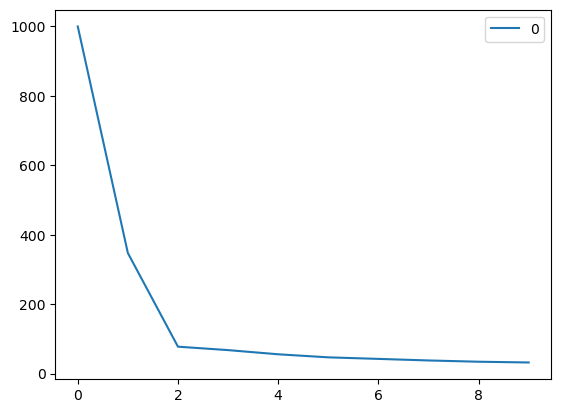

In [46]:
sns.lineplot(data=df)

In [67]:
kmeans_final = KMeans(n_clusters=2, random_state=42)

In [68]:
kmeans_final

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [69]:
cluster_labels = kmeans_final.fit_predict(X_Scaled)

In [70]:
df0['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

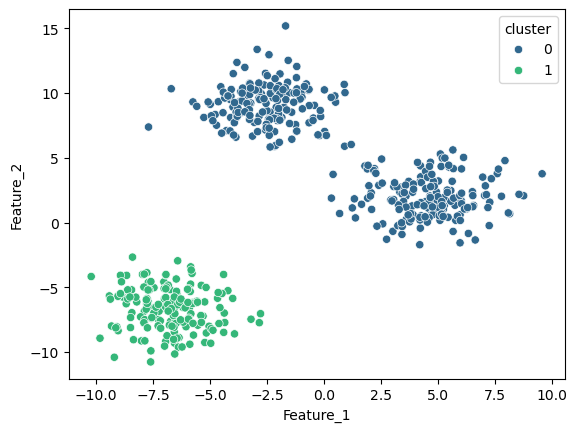

In [71]:
sns.scatterplot(x=df0['Feature_1'],
                y=df0['Feature_2'],
                hue=df0['cluster'],
                palette='viridis')

In [72]:
from sklearn.datasets import make_moons

In [73]:
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [74]:
from sklearn.cluster import KMeans

In [75]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [76]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [77]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [78]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

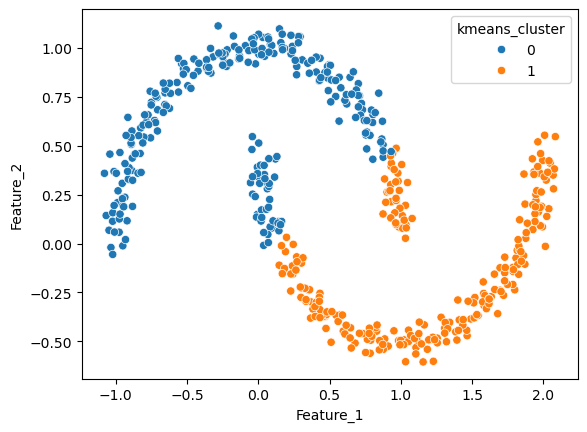

In [79]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')

In [80]:
from sklearn.cluster import DBSCAN

In [81]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [82]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

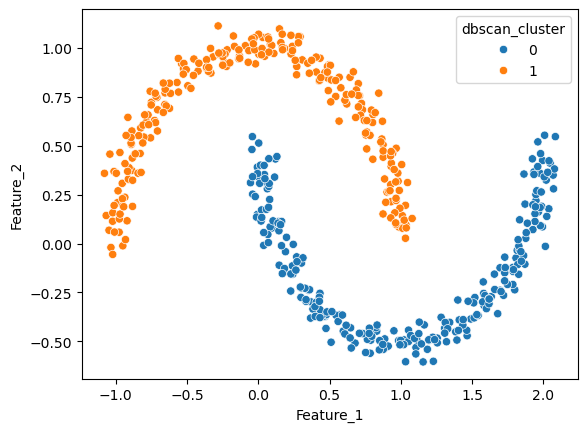

In [83]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')